In [217]:
# =========================
# Simple LR/HR Dataset (hello-world friendly)
# =========================

from dataclasses import dataclass
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import v2
from torchvision.transforms.v2 import functional as TF
import matplotlib.pyplot as plt
from torchvision.transforms.functional import to_pil_image


# -------------------------
# Utils
# -------------------------

def to_minus_one_one(x):
    return x * 2.0 - 1.0

def to_zero_one(x):
    return (x + 1.0) * 0.5


# -------------------------
# Simple augmentation config
# -------------------------

@dataclass
class SimpleAugmentConfig:
    hflip: bool = True

    # Crop bias (pixels)
    max_top_crop: int = 8
    max_bottom_crop: int = 128

    # Color jitter
    color_jitter: bool = True


# -------------------------
# Simple square crop, top-biased
# -------------------------

def top_biased_square_crop(img: torch.Tensor, cfg: SimpleAugmentConfig):
    """
    img: [3, H, W], H == W
    """
    _, H, W = img.shape
    assert H == W

    top = torch.randint(0, cfg.max_top_crop + 1, (1,)).item()
    bottom = torch.randint(0, cfg.max_bottom_crop + 1, (1,)).item()

    total_crop = top + bottom
    if total_crop >= H:
        return img

    new_size = H - total_crop

    # Horizontal crop: center-biased
    max_left = W - new_size
    center = max_left // 2
    jitter = torch.randint(-center // 2, center // 2 + 1, (1,)).item()
    left = max(0, min(max_left, center + jitter))

    return img[:, top:top+new_size, left:left+new_size]

def skin_preserving_color_jitter(img: torch.Tensor, xform) -> torch.Tensor:
    """
    img: [3,H,W] in [-1,1]
    """
    img01 = (img + 1) * 0.5
    r, g, b = img01

    # RGB → YCbCr (ITU-R BT.601-ish)
    y  = 0.299 * r + 0.587 * g + 0.114 * b
    cb = 0.564 * (b - y)
    cr = 0.713 * (r - y)

    # Skin mask
    skin = (
        (cr > 0.05) & (cr < 0.25) &
        (cb > -0.15) & (cb < 0.05) &
        (y > 0.2)
    )

    img02 = xform(img01)
    img = torch.where(skin, img01, img02)
    out = img * 2 - 1
    return torch.clamp(out, -1.0, 1.0)


# -------------------------
# Dataset
# -------------------------

class AugmentedLRHRDataset(Dataset):
    def __init__(self, root, HR, LR, aug: SimpleAugmentConfig | None = None):
        self.HR = HR
        self.LR = LR
        self.aug = aug or SimpleAugmentConfig()

        self.base = datasets.ImageFolder(
            root=root,
            transform=v2.Compose([
                v2.ToImage(),
                v2.ToDtype(torch.float32, scale=True),
                v2.Lambda(to_minus_one_one),
            ])
        )

        self.color = v2.ColorJitter(
            brightness=0.1,
            hue=0.5
        )

    def __len__(self):
        return len(self.base)

    def _resize_if_needed(self, img, size):
        if img.shape[1] == size:
            return img
        out =  F.interpolate(
            img.unsqueeze(0),
            size=(size, size),
            mode="bicubic",
            align_corners=False,
            antialias=True
        ).squeeze(0)
        return torch.clamp(out, -1.0, 1.0)

    def __getitem__(self, idx):
        orig, _ = self.base[idx]

        hr = orig.clone()

        # Flip
        if self.aug.hflip and torch.rand(1) < 0.5:
            hr = torch.flip(hr, dims=[2])

        # Crop
        hr = top_biased_square_crop(hr, self.aug)

        # Resize to HR
        hr = self._resize_if_needed(hr, self.HR)

        # Color jitter (expects [0,1])
        if self.aug.color_jitter:
            hr = skin_preserving_color_jitter(hr, self.color)

        # LR derived from HR
        lr = self._resize_if_needed(hr, self.LR)

        return hr, lr#, orig



In [218]:

# -------------------------
# Visualization helper
# -------------------------
import random
def show_samples(ds, n=4):
    import IPython.display as ipd
    fig, axes = plt.subplots(n, 3, figsize=(6, 3 * n))
    for i in range(n):
        idx = random.randint(0,len(ds))
        #idx=0
        hr, lr,orig = ds[idx]
        
        #ipd.display(to_pil_image(to_zero_one(orig)))
        #ipd.display(to_pil_image(to_zero_one(hr)))
        #ipd.display(to_pil_image(to_zero_one(lr)))
        axes[i, 0].imshow(to_pil_image(to_zero_one(orig)))
        axes[i, 0].set_title("orig")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(to_pil_image(to_zero_one(hr)))
        axes[i, 1].set_title("HR")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(to_pil_image(to_zero_one(lr)))
        axes[i, 2].set_title("LR")
        axes[i, 2].axis("off")
    plt.tight_layout()
    plt.show()


# -------------------------
# Example usage
# -------------------------

aug = SimpleAugmentConfig(
    max_top_crop=8,
    max_bottom_crop=64-8,
    color_jitter=True
)

dataset = LRHRDataset(
    root="../data/256x256/pokemon",
    HR=256,
    LR=64,
    aug=aug
)



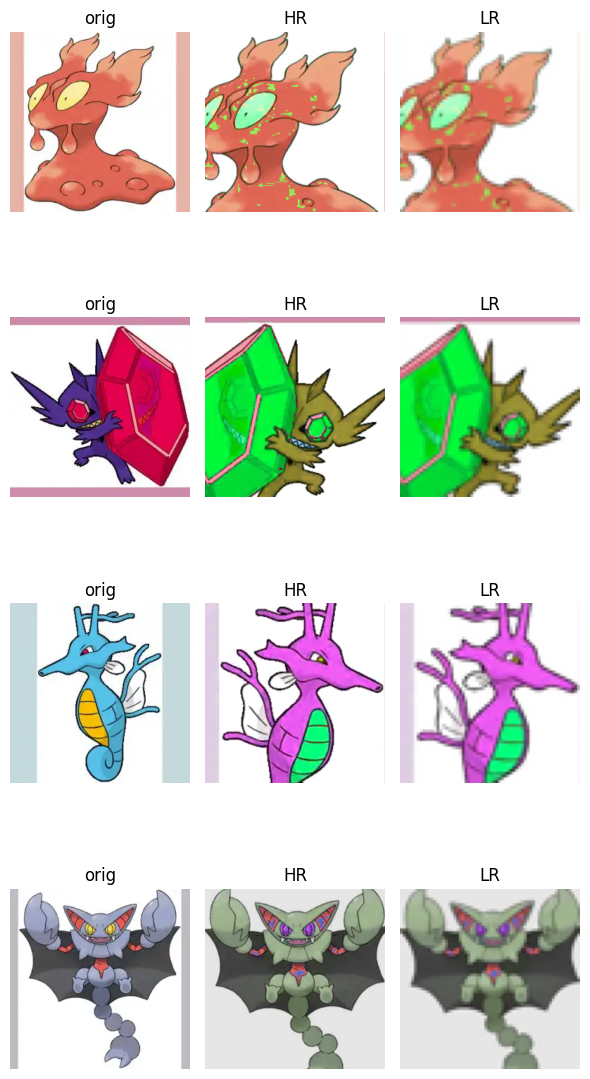

In [219]:
show_samples(dataset)

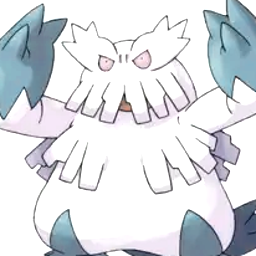

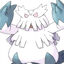

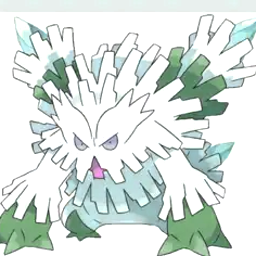

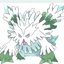

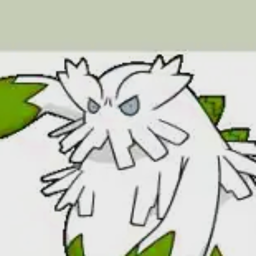

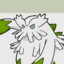

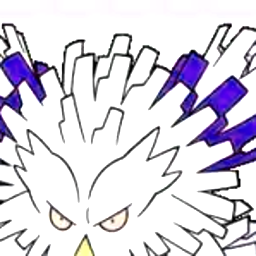

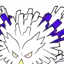

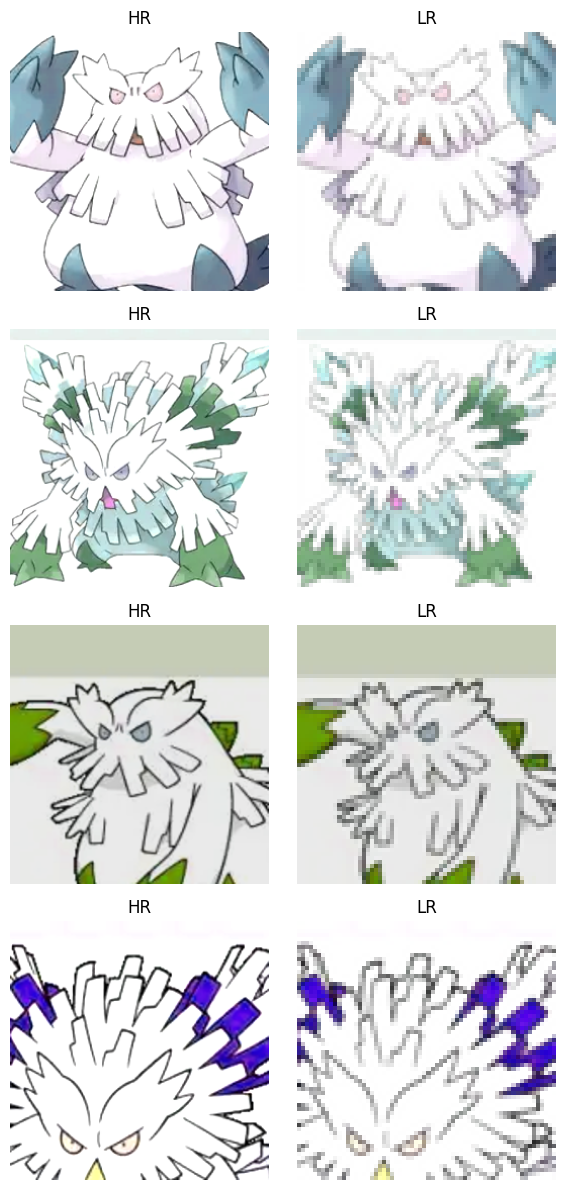

In [21]:
show_samples(dataset)

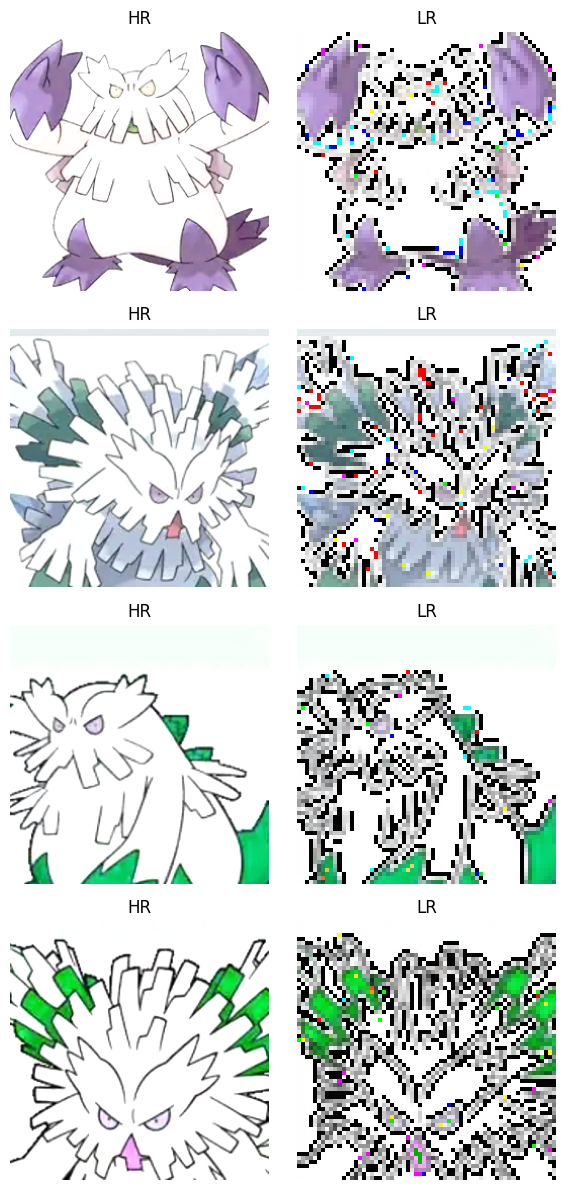

In [13]:
show_samples(dataset)